Could not process file qber16_pass_4_4_4_8.csv: [Errno 2] No such file or directory: 'qber16_pass_4_4_4_8.csv'


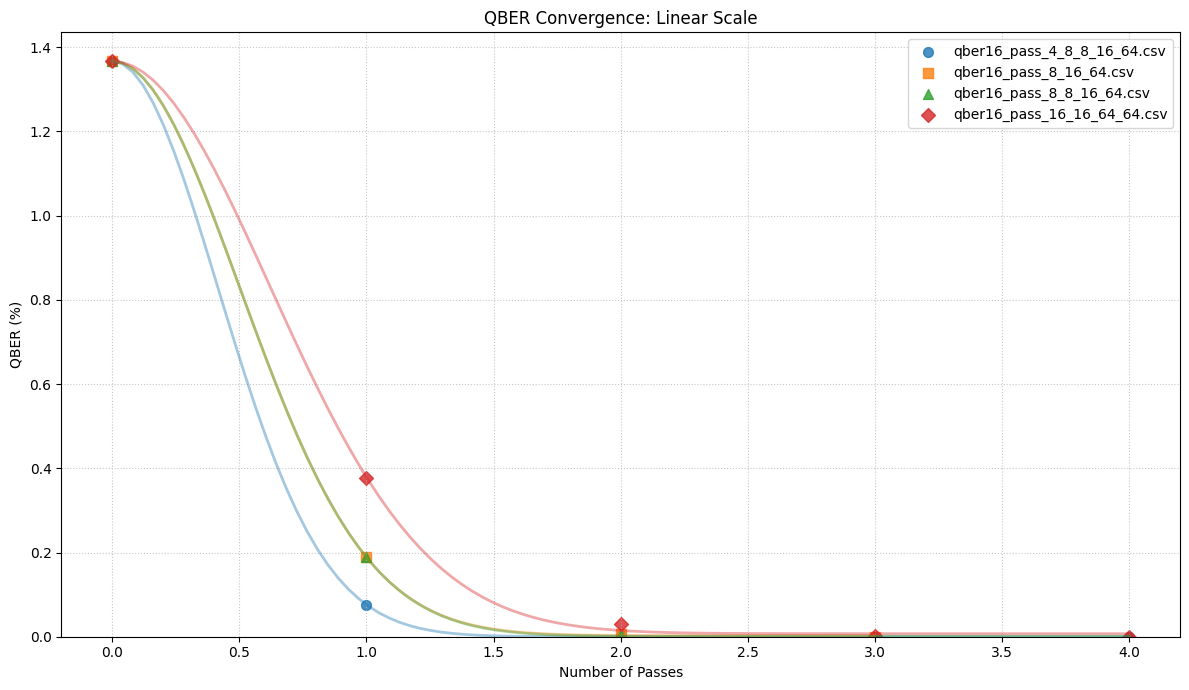

Could not process file qber16_pass_4_4_4_8.csv: [Errno 2] No such file or directory: 'qber16_pass_4_4_4_8.csv'


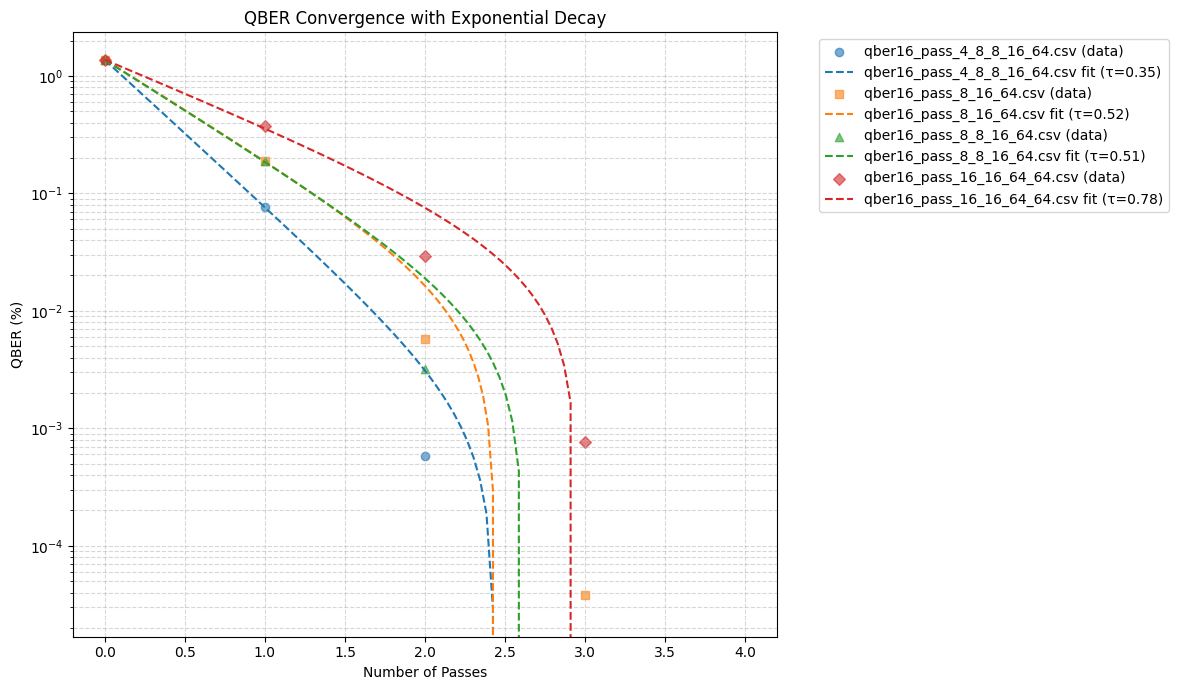

Could not process file qber16_pass_4_4_4_8.csv: [Errno 2] No such file or directory: 'qber16_pass_4_4_4_8.csv'


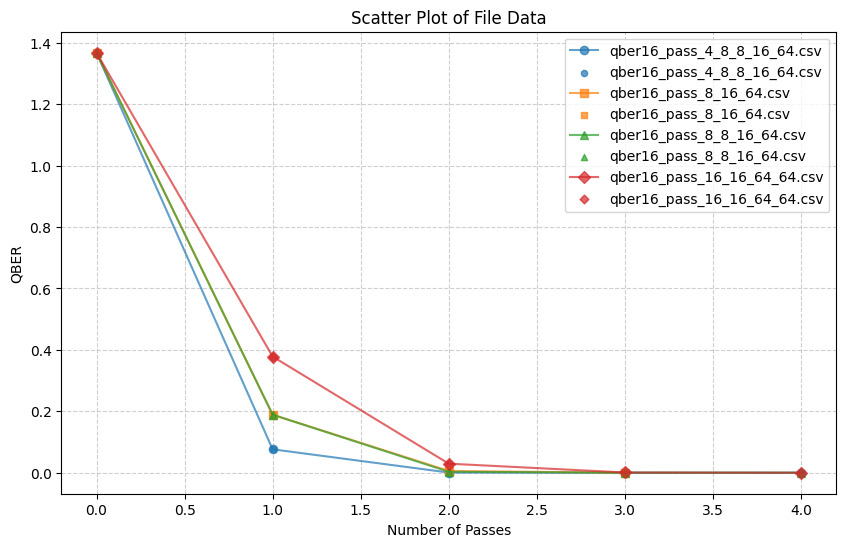

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib.pyplot as plt

# for i in np.arange(4):
#     plt.plot(num_pass_for_schedule[i], qber_for_schedule[i], label = f"{many_block_schedules[i]}")
#     plt.legend()
#     plt.show()
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
from lmfit.models import ExpressionModel, ConstantModel, ExponentialModel

def plot_files_with_custom_fit(file_list, title="QBER Convergence: Super-Exponential Fit"):
    plt.figure(figsize=(12, 7))
    markers = ['o', 's', '^', 'D', 'x', '*', 'v', '<', '>', 'p']
    
    # Custom Steeper Model: y = A * exp(-k * x^2) + c
    # This 'Gaussian-style' decay is much steeper than linear exponential
    steeper_model = ExpressionModel("amplitude * exp(-k * x**2) + c")

    for i, file in enumerate(file_list):
        try:
            df = pd.read_csv(file)
            df = df.dropna(subset=['Pass_Number', 'QBER'])
            
            x = df['Pass_Number'].values
            y = df['QBER'].values
            y = np.where(y == 0, 1e-10, y)
            color = plt.cm.tab10(i % 10)

            plt.scatter(x, y, alpha=0.6, marker=markers[i % len(markers)], 
                        color=color, label=f"{os.path.basename(file)} (data)")

            if len(x) >= 3:
                # Initial guesses:
                # amplitude is starting QBER, k is the decay rate, c is the floor
                params = steeper_model.make_params(amplitude=y.max(), k=0.1, c=1)
                
                # Constrain parameters to keep the fit physically realistic
                params['amplitude'].set(min=1e-9)
                params['k'].set(min=1e-9)
                
                result = steeper_model.fit(y, params, x=x)

                # Create smooth fit line
                x_fit = np.logspace(np.exp(x.min()), np.exp(x.max()), 100)
                y_fit = result.eval(x=x_fit)
                
                plt.plot(x_fit, y_fit, '--', color=color, 
                         label=f"Steep Fit (k={result.params['k'].value:.3f})")
            
        except Exception as e:
            print(f"Could not process file {file}: {e}")

    plt.title(title)
    plt.xlabel("Number of Passes")
    plt.ylabel("QBER (%)")
    # plt.yscale('log') # QBER decay is often clearer on a log scale
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, which="both", linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    

def plot_files_scatter(file_list, title="Scatter Plot of File Data"):
    plt.figure(figsize=(10, 6))
    
    # List of different marker styles
    # 'o' = circle, 's' = square, '^' = triangle, 'D' = diamond, 'x' = x, '*' = star
    markers = ['o', 's', '^', 'D', 'x', '*', 'v', '<', '>', 'p']
    
    for i, file in enumerate(file_list):
        try:
            df = pd.read_csv(file)
            label = os.path.basename(file)
            
            # Use the modulo operator (%) to loop back to the start 
            # of the marker list if you have more files than markers
            current_marker = markers[i % len(markers)]
            
            plt.plot(
                df['Pass_Number'], 
                df['QBER'], 
                label=label, 
                alpha=0.7, 
                # s=10,                 # Increased size slightly to make shapes visible
                marker=current_marker # This sets the shape
            )
            plt.scatter(
                df['Pass_Number'], 
                df['QBER'], 
                label=label, 
                alpha=0.7, 
                s=20,                 # Increased size slightly to make shapes visible
                marker=current_marker # This sets the shape
            )
            
            
        except Exception as e:
            print(f"Could not process file {file}: {e}")

    plt.title(title)
    plt.xlabel("Number of Passes")
    plt.ylabel("QBER")
    plt.legend()
    # plt.xscale('log')
    # plt.yscale('log')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
# Example Usage:




def plot_files_linear(file_list, title="QBER Convergence: Linear Scale"):
    plt.figure(figsize=(12, 7))
    markers = ['o', 's', '^', 'D', 'x', '*', 'v', '<', '>', 'p']
    
    # Super-steeper model for linear view
    steeper_model = ExpressionModel("amplitude * exp(-k * x**2) + c")

    for i, file in enumerate(file_list):
        try:
            df = pd.read_csv(file)
            df = df.dropna(subset=['Pass_Number', 'QBER'])
            
            x = df['Pass_Number'].values
            y = df['QBER'].values
            color = plt.cm.tab10(i % 10)

            # Scatter plot of raw data
            plt.scatter(x, y, alpha=0.8, marker=markers[i % len(markers)], 
                        color=color, s=50, label=f"{os.path.basename(file)}")

            if len(x) >= 3:
                # Fit the steeper model
                params = steeper_model.make_params(amplitude=y.max(), k=0.1, c=0)
                result = steeper_model.fit(y, params, x=x)

                x_fit = np.linspace(x.min(), x.max(), 100)
                y_fit = result.eval(x=x_fit)
                
                plt.plot(x_fit, y_fit, '-', color=color, alpha=0.4, linewidth=2)
            
        except Exception as e:
            print(f"Could not process file {file}: {e}")

    plt.title(title)
    plt.xlabel("Number of Passes")
    plt.ylabel("QBER (%)")
    
    # Ensure the y-axis starts at 0 and goes slightly above your max QBER
    plt.ylim(0, None) 
    
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()

# many_block_schedules = [
#     [4,4,0,0,0,0,0,0],
#     [4,2,2,0,0,0,0,0],
#     # # [4,2,1,0,0,0,0,0],
#     # # [4,1,0,0,0,0,0,0],
#     [2,2,0,0,0,0,0,0],
#     [2,2,4,4,4,4,4,4],
#     # [1,1,0,0,0,0,0,0]
# ]

# output_file_names = [
#     'qber_pass_44000000.csv',
#     'qber_pass_42200000.csv',
#     # # 'qber_pass_42100000.csv',
#     # # 'qber_pass_41000000.csv',
#     'qber_pass_22000000.csv',
#     'qber_pass_22444444.csv'
#     # 'qber_pass_11000000.csv'
# ]


many_block_schedules = [
    [4,8,8,16,64],
    [8,16,64],
    [8,8,16,64],
    [16,16,64,64],
    [4,4,4,8]
    # [8,16,64,0,0,0,0,0],

    # [4,2,2,0,0,0,0,0],
    # [4,2,1,0,0,0,0,0],
    # # # [8,4,1,0,0,0,0,0],
    # [2,2,0,0,0,0,0,0],
    # # [1,1,0,0,0,0,0,0]
]

output_file_names = [
    'qber16_pass_4_8_8_16_64.csv',
    'qber16_pass_8_16_64.csv',
    'qber16_pass_8_8_16_64.csv',
    'qber16_pass_16_16_64_64.csv',
    'qber16_pass_4_4_4_8.csv',
    # 'qber8_pass_42200000.csv',
    # 'qber8_pass_42100000.csv',
    # # 'qber_pass_41000000.csv',
    # 'qber8_pass_22000000.csv',
    # # 'qber4_pass_11000000.csv'
]

plot_files_linear(output_file_names, title="QBER Convergence: Linear Scale")
plot_files_with_fit(output_file_names)
plot_files_scatter(output_file_names)

Error processing qber16_pass_4_4_4_8.csv: [Errno 2] No such file or directory: 'qber16_pass_4_4_4_8.csv'


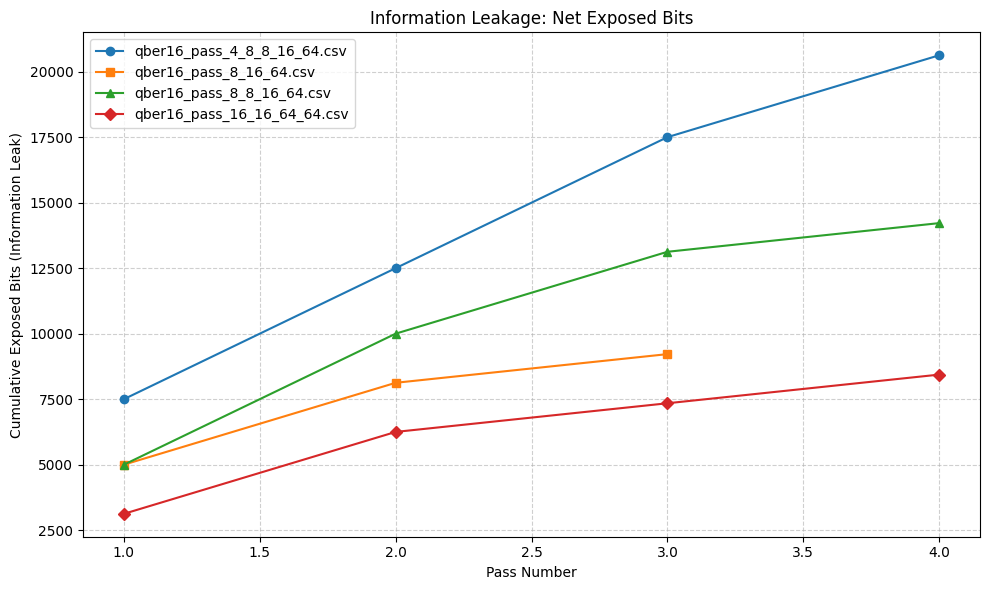

In [30]:
def plot_exposed_bits(file_list, title="Information Leakage: Net Exposed Bits"):
    plt.figure(figsize=(10, 6))
    markers = ['o', 's', '^', 'D', 'x', '*', 'v', '<', '>', 'p']

    for i, file in enumerate(file_list):
        try:
            df = pd.read_csv(file)
            df = df.dropna(subset=['Pass_Number', 'Block_Size'])
            
            # If your CSV doesn't have 'Num_Blocks', we approximate based on a 
            # typical key length (e.g., 10000 bits) or use the column if available.
            # Replace 10000 with your actual key length if known.
            key_len = 10000 
            
            # Calculate syndrome length for each pass
            df['Syndrome_Len'] = np.ceil(np.log2(df['Block_Size'] + 1))
            
            # Calculate bits exposed in THIS pass
            # Exposed = (Total Key Bits / Block Size) * Syndrome Length
            df['Pass_Exposed'] = (key_len / df['Block_Size']) * df['Syndrome_Len']
            
            # Net Exposed is the Cumulative Sum
            df['Net_Exposed'] = df['Pass_Exposed'].cumsum()

            color = plt.cm.tab10(i % 10)
            label = os.path.basename(file)

            plt.plot(df['Pass_Number'], df['Net_Exposed'], 
                     marker=markers[i % len(markers)], 
                     linestyle='-', 
                     color=color, 
                     label=label)

        except Exception as e:
            print(f"Error processing {file}: {e}")

    plt.title(title)
    plt.xlabel("Pass Number")
    plt.ylabel("Cumulative Exposed Bits (Information Leak)")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()


many_block_schedules = [
    [4,8,8,16,64],
    [8,16,64],
    [8,8,16,64],
    [16,16,64,64],
    [4,4,4,8]
    # [8,16,64,0,0,0,0,0],

    # [4,2,2,0,0,0,0,0],
    # [4,2,1,0,0,0,0,0],
    # # # [8,4,1,0,0,0,0,0],
    # [2,2,0,0,0,0,0,0],
    # # [1,1,0,0,0,0,0,0]
]

output_file_names = [
    'qber16_pass_4_8_8_16_64.csv',
    'qber16_pass_8_16_64.csv',
    'qber16_pass_8_8_16_64.csv',
    'qber16_pass_16_16_64_64.csv',
    'qber16_pass_4_4_4_8.csv',
    # 'qber8_pass_42200000.csv',
    # 'qber8_pass_42100000.csv',
    # # 'qber_pass_41000000.csv',
    # 'qber8_pass_22000000.csv',
    # # 'qber4_pass_11000000.csv'
]


plot_exposed_bits(output_file_names)